In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as psx
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

In [4]:
data = pd.read_csv("loan_data.csv")

In [5]:
data.loan_percent_income.max()

np.float64(0.66)

In [6]:
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [46]:
df = pd.read_csv("loan_data.csv")

In [47]:
df.loan_status.value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [45]:
data[data.previous_loan_defaults_on_file == "No"]["loan_status"].argmax()

np.int64(0)

In [6]:
data.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [8]:
data.corr(numeric_only = True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


In [9]:
data.iloc[:,[0,4,11]]

,person_age,person_emp_exp,credit_score
0,22.0,0,561
1,21.0,0,504
2,25.0,3,635
3,23.0,0,675
4,24.0,1,586
...,...,...,...
44995,27.0,6,645
44996,37.0,17,621
44997,33.0,7,668
44998,29.0,4,604


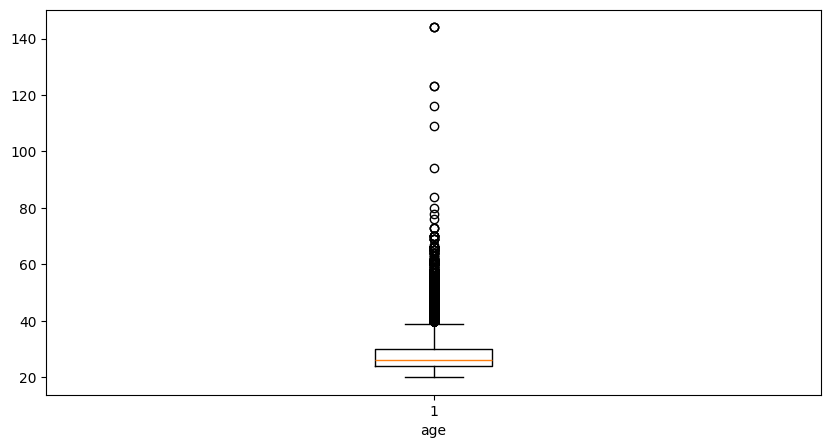

In [10]:
#Outliers Detection
plt.figure(figsize=(10,5))
plt.boxplot(data.iloc[:,[0]])
plt.xlabel("age")
plt.show()

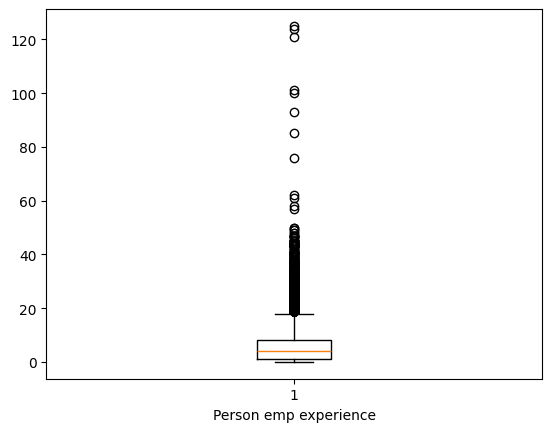

In [11]:
plt.boxplot(data.iloc[:,[4]])
plt.xlabel("Person emp experience")
plt.show()

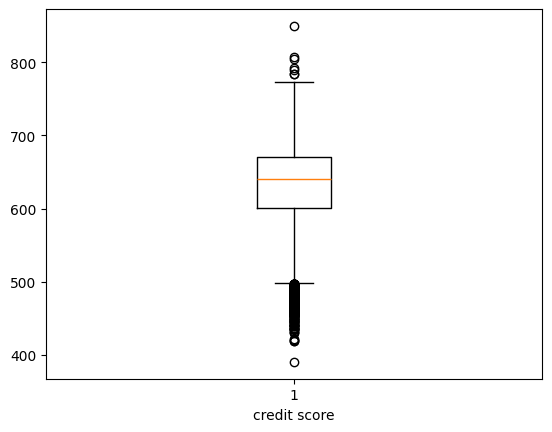

In [12]:
plt.boxplot(data.iloc[:,[11]])
plt.xlabel("credit score")
plt.show()

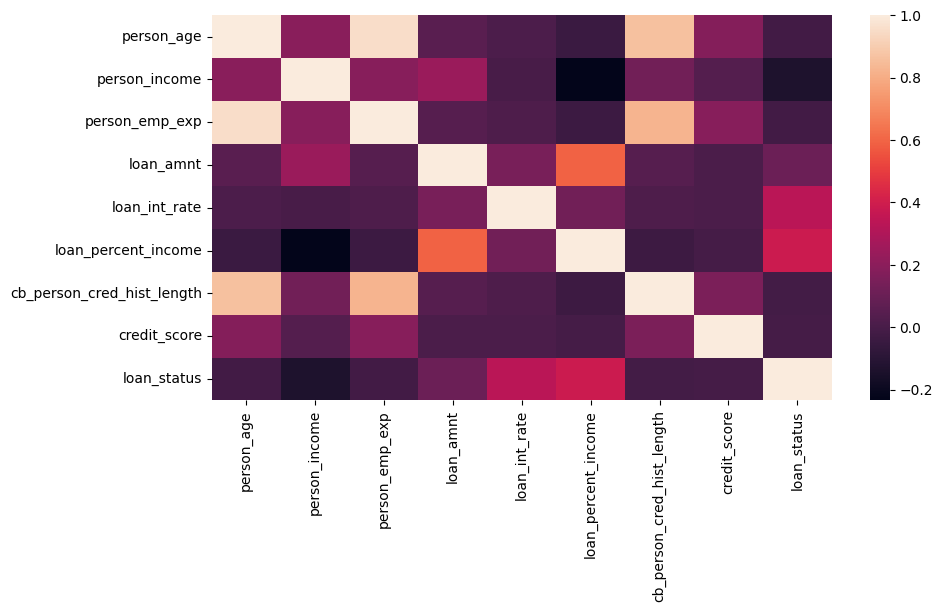

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(numeric_only=True))
plt.show()

In [14]:
new_data = data[data.person_age < 100]

In [15]:
new_data.loan_amnt = new_data.loan_amnt*91.94
new_data.person_income = new_data.person_income*91.86

C:\Users\lipun\AppData\Local\Temp\ipykernel_13372\3815968867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data.loan_amnt = new_data.loan_amnt*91.94
C:\Users\lipun\AppData\Local\Temp\ipykernel_13372\3815968867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data.person_income = new_data.person_income*91.86


In [16]:
valid = new_data.to_csv("Data/Validation.csv",index=False)

In [ ]:
new_data.describe().astype(int)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993,44993,44993,44993,44993,44993,44993,44993,44993
mean,27,7340389,5,881077,11,0,5,632,0
std,5,5816771,5,580582,2,0,3,50,0
min,20,734880,0,45970,5,0,2,390,0
25%,24,4335332,1,459700,8,0,3,601,0
50%,26,6158845,4,735520,11,0,4,640,0
75%,30,8798167,8,1125069,12,0,8,670,0
max,94,224933999,76,3217900,20,0,30,784,1


: 

In [18]:
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

<h1><b>Final Report: Data Validation</b></h1>
<li>
    Missing Values in Features: "Gender","Married","Dependence","Self_Employed" of type OBJ. SimpleImputer to fill in missing values.<br>
    Missing Values in Features: "LoanAmount","Loan_Amount_Term","Credit_History" of type Float.KNNImputer is used for impute missing values
</li>
<li>
    Converted Datatype Float to Int For Numerical Features Like  "LoanAmount","Loan_Amount_Term","Credit_History","CoapplicantIncome"
</li>
<li>
    Outliers Detected in Features "ApplicantIncome" and "CoapplicantIncome" But it makes sense in terms of real-case scenarios.
</li>
<li>
    No Dependencies Among Features
</li>